In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Bagian A: Operasi pada Sinyal 1D

A.1 Membuat Sinyal Diskrit

<Figure size 1200x500 with 0 Axes>

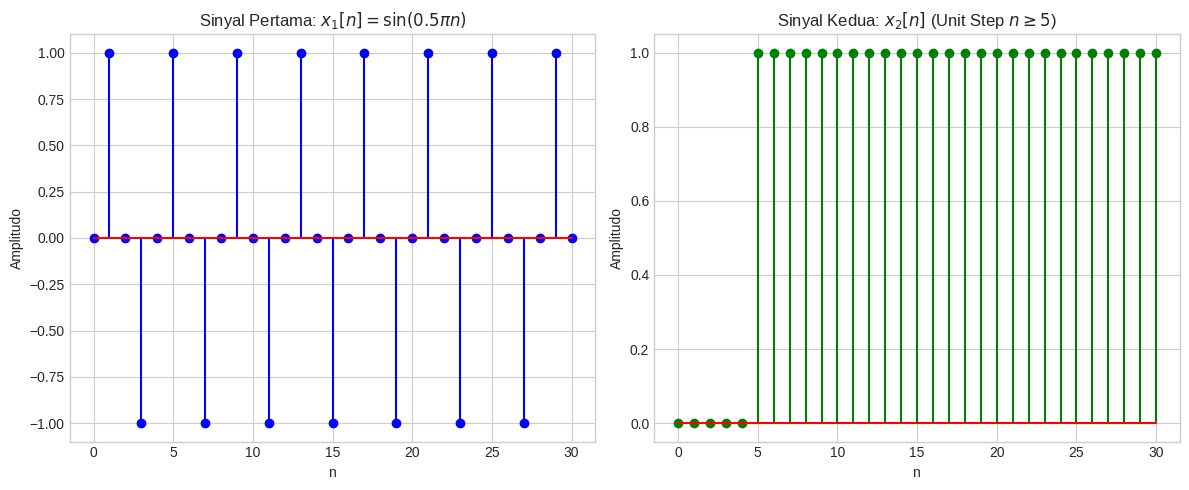

In [ ]:
# Menentukan rentang n
n = np.arange(0, 31)

# Sinyal pertama: Sinusoidal
x1 = np.sin(0.5 * np.pi * n)

# Sinyal kedua: Unit Step (n >= 5)
x2 = np.where(n >= 5, 1.0, 0.0)

# Visualisasi Sinyal Asli
plt.figure(figsize=(12, 5))

# Visualisasi Sinyal Asli (Sudah Diperbaiki)
plt.figure(figsize=(12, 5))

# Tambahkan r'...' di awal string title
plt.subplot(1, 2, 1)
plt.stem(n, x1, linefmt='b-', markerfmt='bo', basefmt='r-')
plt.title(r'Sinyal Pertama: $x_1[n] = \sin(0.5\pi n)$') # Menggunakan r' dan \sin aman
plt.xlabel('n')
plt.ylabel('Amplitudo')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.stem(n, x2, linefmt='g-', markerfmt='go', basefmt='r-')
plt.title(r'Sinyal Kedua: $x_2[n]$ (Unit Step $n \geq 5$)') # Menggunakan r' dan \geq
plt.xlabel('n')
plt.ylabel('Amplitudo')
plt.grid(True)

plt.tight_layout()
plt.show()

A.2 Operasi Penjumlahan Sinyal

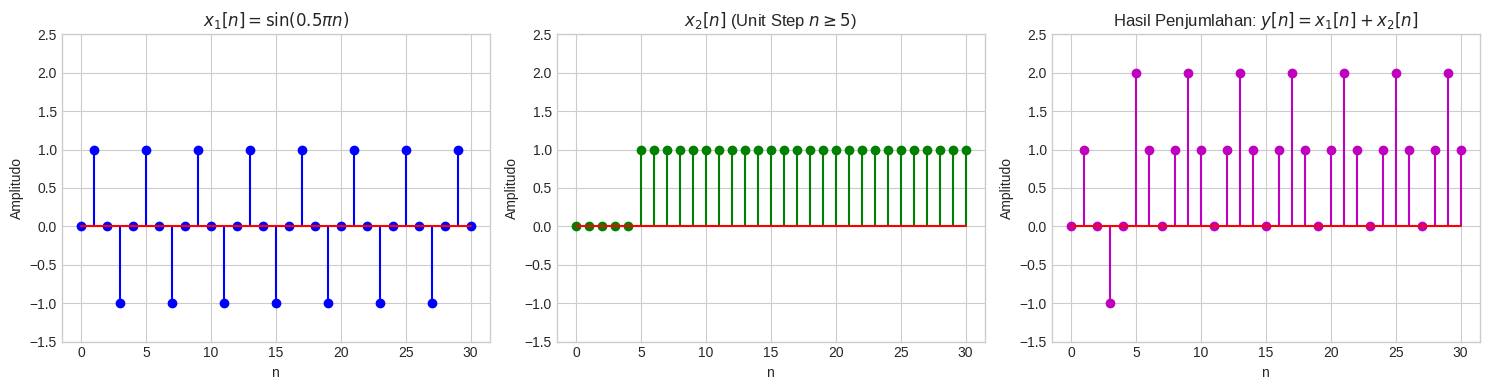

In [ ]:
# Operasi Penjumlahan Sinyal element-wise
y_add = x1 + x2

# Visualisasi Proses dan Hasil Penjumlahan
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.stem(n, x1, linefmt='b-', markerfmt='bo', basefmt='r-')
plt.title(r'$x_1[n] = \sin(0.5\pi n)$')
plt.xlabel('n')
plt.ylabel('Amplitudo')
plt.ylim(-1.5, 2.5)
plt.grid(True)

plt.subplot(1, 3, 2)
plt.stem(n, x2, linefmt='g-', markerfmt='go', basefmt='r-')
plt.title(r'$x_2[n]$ (Unit Step $n \geq 5$)')
plt.xlabel('n')
plt.ylabel('Amplitudo')
plt.ylim(-1.5, 2.5)
plt.grid(True)

plt.subplot(1, 3, 3)
plt.stem(n, y_add, linefmt='m-', markerfmt='mo', basefmt='r-')
plt.title(r'Hasil Penjumlahan: $y[n] = x_1[n] + x_2[n]$')
plt.xlabel('n')
plt.ylabel('Amplitudo')
plt.ylim(-1.5, 2.5) # Batas sumbu y disamakan agar efek pergeseran terlihat jelas
plt.grid(True)

plt.tight_layout()
plt.show()

A.3 Operasi Penggeseran Sinyal

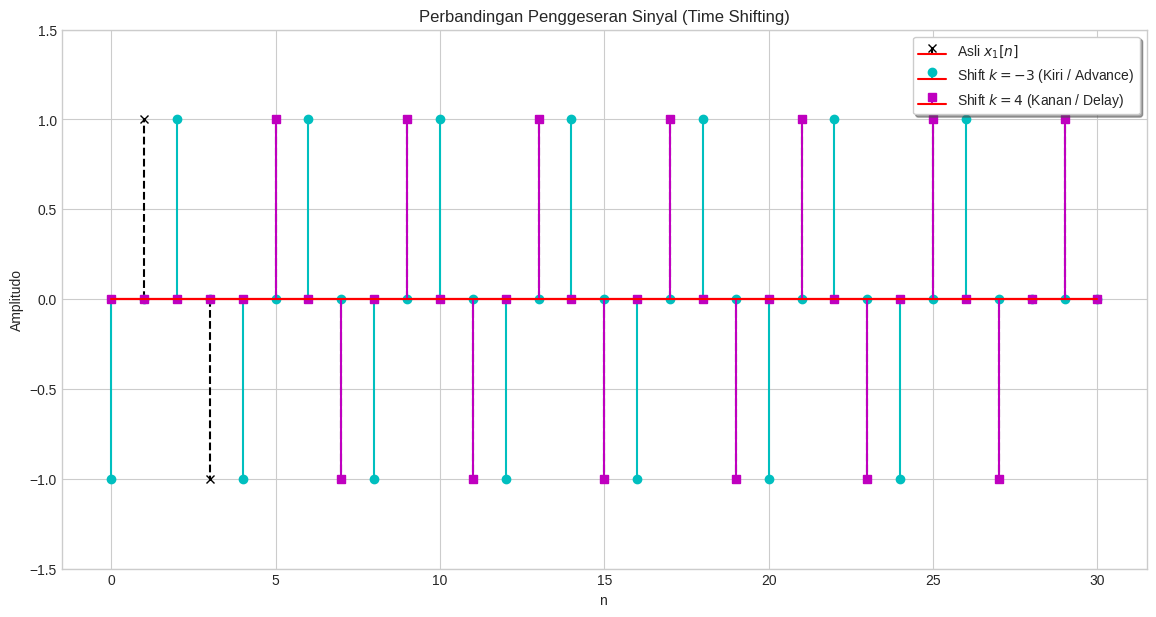

In [ ]:
def shift_signal(x, k):
    shifted = np.zeros_like(x)
    for n_idx in range(len(x)):
        if 0 <= n_idx - k < len(x):
            shifted[n_idx] = x[n_idx - k]
    return shifted

# Melakukan penggeseran sesuai instruksi soal
x_shift_neg = shift_signal(x1, -3) # k = -3
x_shift_zero = shift_signal(x1, 0)  # k = 0 (Sinyal asli)
x_shift_pos = shift_signal(x1, 4)  # k = 4

# Visualisasi Perbandingan dalam Satu Gambar (Sesuai Ketentuan Output)
plt.figure(figsize=(14, 7))

plt.stem(n, x1, linefmt='k--', markerfmt='kx', label=r'Asli $x_1[n]$', basefmt='r-')
plt.stem(n, x_shift_neg, linefmt='c-', markerfmt='co', label=r'Shift $k=-3$ (Kiri / Advance)', basefmt='r-')
plt.stem(n, x_shift_pos, linefmt='m-', markerfmt='ms', label=r'Shift $k=4$ (Kanan / Delay)', basefmt='r-')

plt.title('Perbandingan Penggeseran Sinyal (Time Shifting)')
plt.xlabel('n')
plt.ylabel('Amplitudo')
plt.ylim(-1.5, 1.5)
plt.legend(loc='upper right', frameon=True, shadow=True)
plt.grid(True)

plt.show()

A.4 Operasi Amplifikasi Sinyal

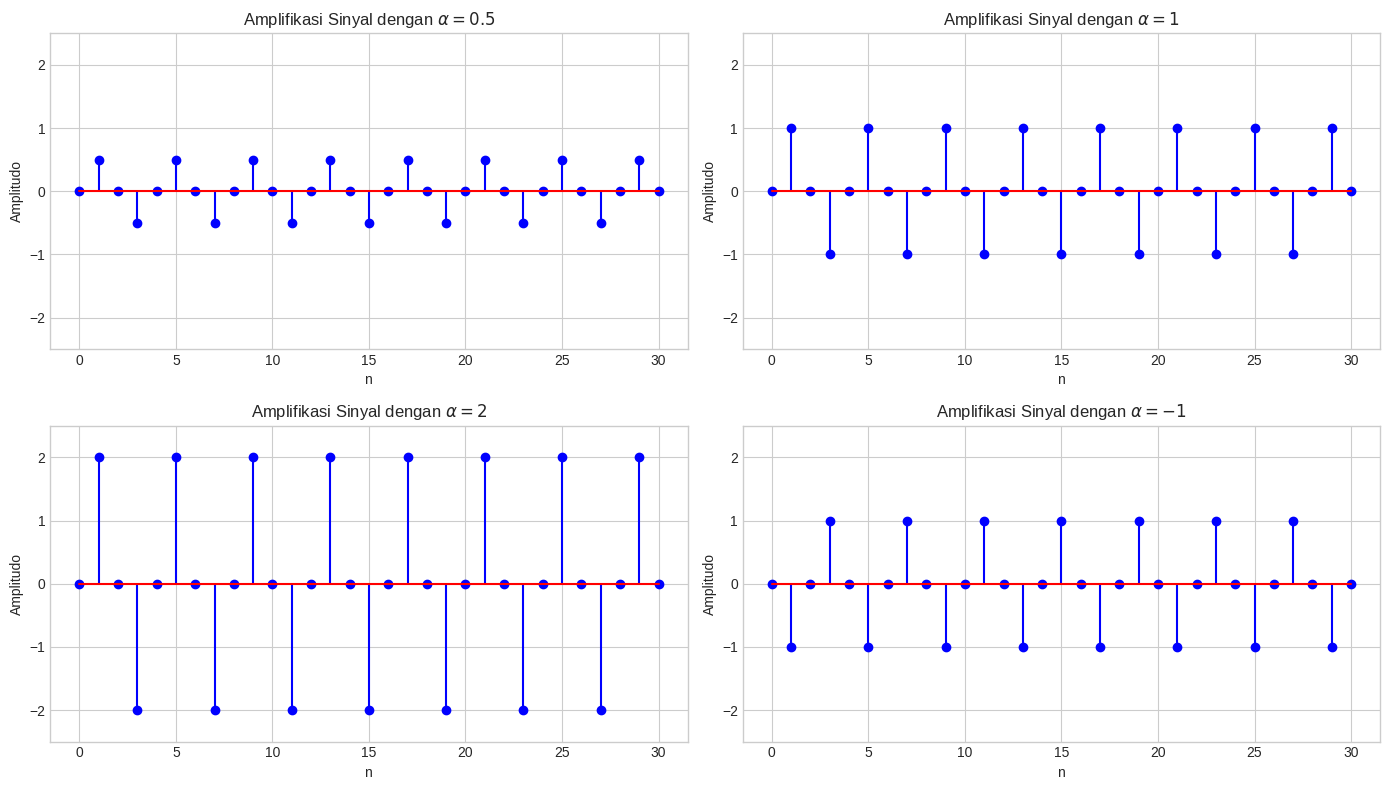

In [ ]:
# Menentukan nilai alpha sesuai instruksi tugas
alphas = [0.5, 1, 2, -1]

# Visualisasi Hasil Amplifikasi Sinyal
plt.figure(figsize=(14, 8))

for i, a in enumerate(alphas, 1):
    plt.subplot(2, 2, i)
    plt.stem(n, a * x1, linefmt='b-', markerfmt='bo', basefmt='r-')
    plt.title(f'Amplifikasi Sinyal dengan $\\alpha = {a}$')
    plt.xlabel('n')
    plt.ylabel('Amplitudo')
    plt.ylim(-2.5, 2.5) # Batas y disamakan agar perubahan skala terlihat kontras
    plt.grid(True)

plt.tight_layout()
plt.show()

# Bagian B: Operasi pada Citra 2D

B.1 Membaca dan Menampilkan Citra

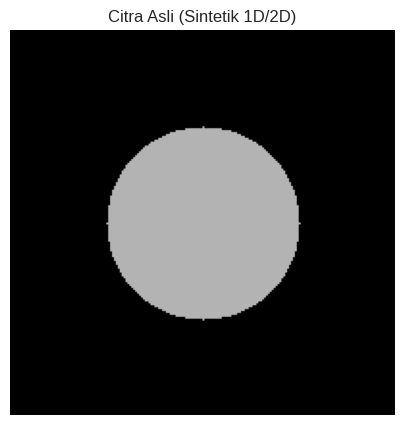

=== METADATA CITRA UTAMA ===
Ukuran Citra              : (200, 200) pixel
Tipe Data Citra           : uint8
Nilai Minimum Pixel       : 0
Nilai Maksimum Pixel       : 180


In [ ]:
# 1. Membuat citra sintetik pertama (Lingkaran abu-abu di tengah latar hitam)
img1 = np.zeros((200, 200), dtype=np.uint8)
cv2.circle(img1, (100, 100), 50, 180, -1)

# 2. Membuat citra sintetik kedua untuk kebutuhan operasi penjumlahan nanti (Kotak abu-abu)
img2 = np.zeros((200, 200), dtype=np.uint8)
cv2.rectangle(img2, (70, 70), (130, 130), 100, -1)

# Visualisasi Citra Utama (Citra 1)
plt.figure(figsize=(5, 5))
plt.imshow(img1, cmap='gray', vmin=0, vmax=255)
plt.title('Citra Asli (Sintetik 1D/2D)')
plt.axis('off') # Menghilangkan sumbu koordinat agar rapi
plt.show()

# Menampilkan Metadata Citra yang Wajib Dicantumkan di Laporan
print("=== METADATA CITRA UTAMA ===")
print(f"Ukuran Citra              : {img1.shape} pixel")
print(f"Tipe Data Citra           : {img1.dtype}")
print(f"Nilai Minimum Pixel       : {img1.min()}")
print(f"Nilai Maksimum Pixel       : {img1.max()}")

B.2 Operasi Penjumlahan Citra

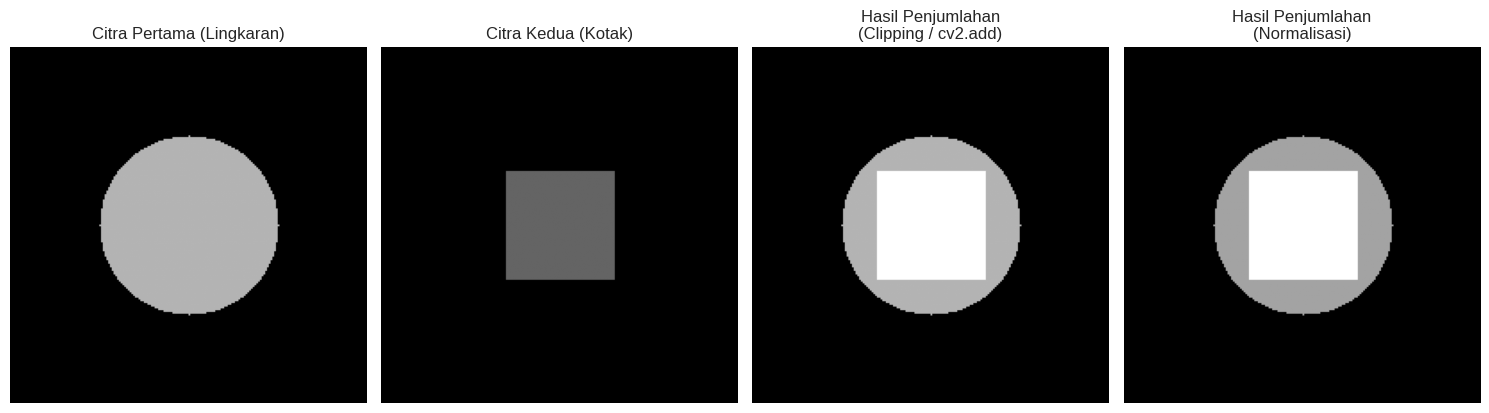

In [ ]:
# Penjumlahan dengan metode Clipping (Saturating Addition dari OpenCV)
img_blend_clip = cv2.add(img1, img2)

# Penjumlahan dengan metode Normalisasi (Menggunakan operasi float lalu diskalakan ulang)
img_sum_float = img1.astype(float) + img2.astype(float)
img_blend_norm = cv2.normalize(img_sum_float, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Visualisasi Hasil Sesuai Ketentuan Tugas
plt.figure(figsize=(15, 4))

plt.subplot(1, 4, 1)
plt.imshow(img1, cmap='gray', vmin=0, vmax=255)
plt.title('Citra Pertama (Lingkaran)')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(img2, cmap='gray', vmin=0, vmax=255)
plt.title('Citra Kedua (Kotak)')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(img_blend_clip, cmap='gray', vmin=0, vmax=255)
plt.title('Hasil Penjumlahan\n(Clipping / cv2.add)')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(img_blend_norm, cmap='gray', vmin=0, vmax=255)
plt.title('Hasil Penjumlahan\n(Normalisasi)')
plt.axis('off')

plt.tight_layout()
plt.show()

B.3 Operasi Penggeseran Citra (Translasi)

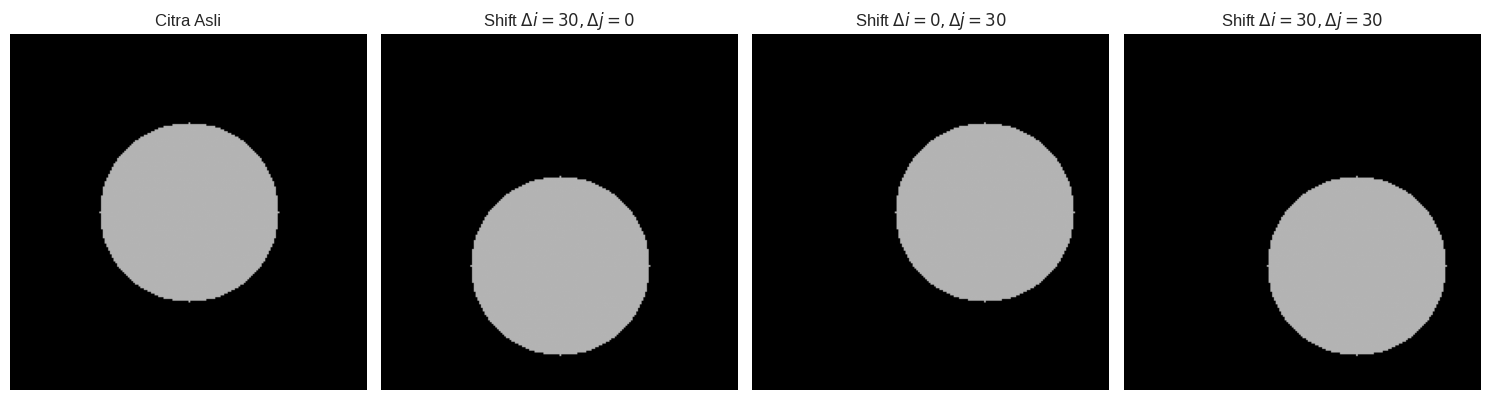

In [ ]:
def translate_image(image, dx, dy):
    rows, cols = image.shape[:2]
    # Matriks transformasi translasi M = [[1, 0, dx], [0, 1, dy]]
    M = np.float32([[1, 0, dx], [0, 1, dy]])
    # Menggunakan cv2.warpAffine untuk menggeser citra
    return cv2.warpAffine(image, M, (cols, rows))

# Melakukan penggeseran sesuai kombinasi pada dokumen tugas
img_shift1 = translate_image(img1, 0, 30)   # Delta i=30 (Y), Delta j=0 (X)
img_shift2 = translate_image(img1, 30, 0)   # Delta i=0 (Y), Delta j=30 (X)
img_shift3 = translate_image(img1, 30, 30) # Delta i=30 (Y), Delta j=30 (X)

# Visualisasi perbandingan hasil penggeseran citra
plt.figure(figsize=(15, 4))

plt.subplot(1, 4, 1)
plt.imshow(img1, cmap='gray', vmin=0, vmax=255)
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(img_shift1, cmap='gray', vmin=0, vmax=255)
plt.title(r'Shift $\Delta i=30, \Delta j=0$')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(img_shift2, cmap='gray', vmin=0, vmax=255)
plt.title(r'Shift $\Delta i=0, \Delta j=30$')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(img_shift3, cmap='gray', vmin=0, vmax=255)
plt.title(r'Shift $\Delta i=30, \Delta j=30$')
plt.axis('off')

plt.tight_layout()
plt.show()

B.4 Operasi Amplifikasi Citra

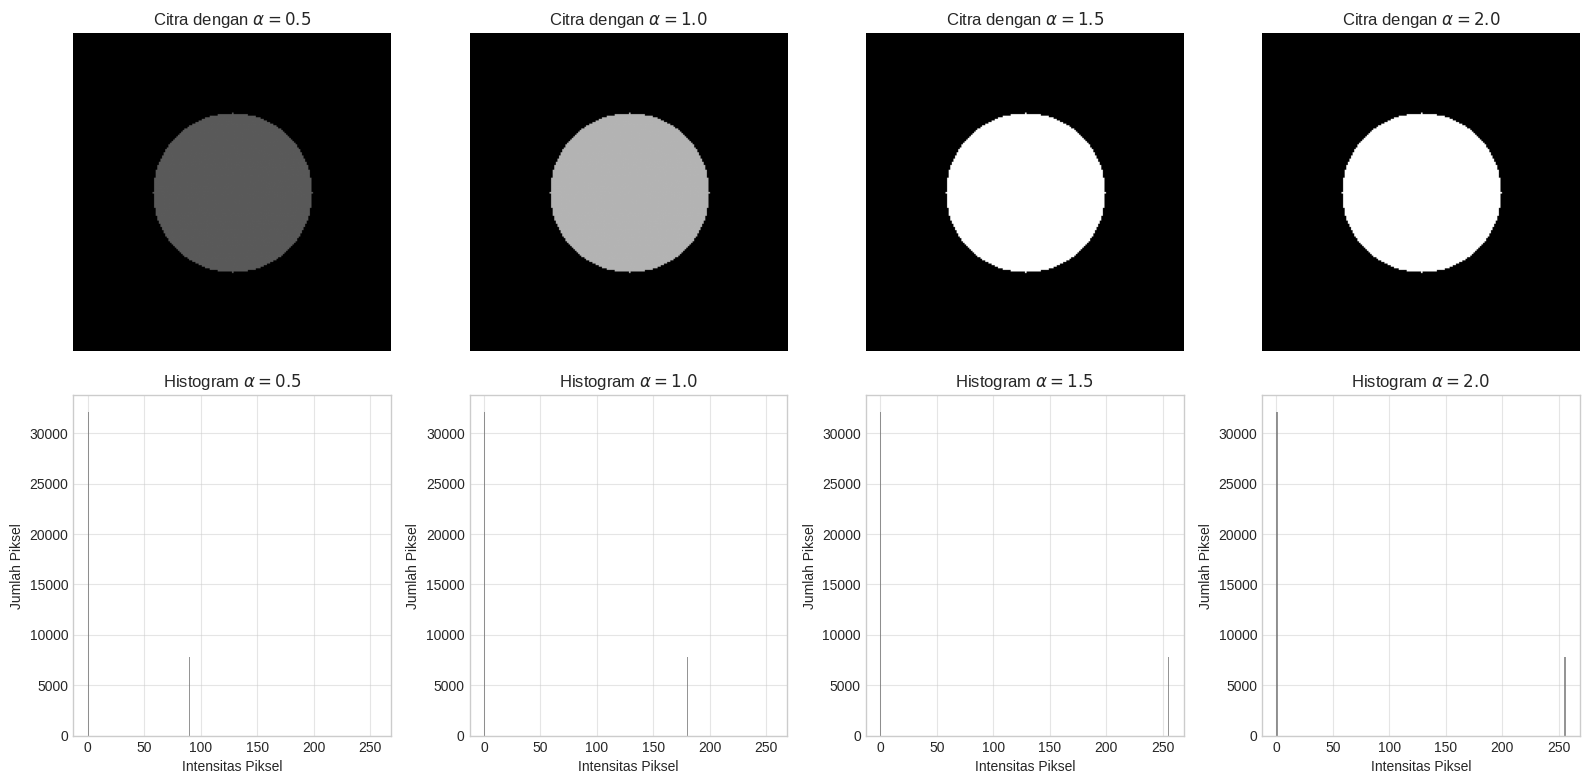

In [ ]:
# Menentukan nilai alpha untuk amplifikasi citra
alphas_img = [0.5, 1.0, 1.5, 2.0]

# Setup layout plot: 2 baris, 4 kolom (Baris 1 untuk Citra, Baris 2 untuk Histogram)
plt.figure(figsize=(16, 8))

for i, a in enumerate(alphas_img, 1):
    # Menggunakan cv2.multiply agar otomatis menerapkan clipping pada nilai > 255
    # Ini mencegah terjadinya overflow integer yang merusak visual citra
    amp_img = cv2.multiply(img1, np.array([a]))

    # 1. Menampilkan Citra Hasil Amplifikasi
    plt.subplot(2, 4, i)
    plt.imshow(amp_img, cmap='gray', vmin=0, vmax=255)
    plt.title(f'Citra dengan $\\alpha = {a}$')
    plt.axis('off')

    # 2. Menampilkan Histogram Citra
    plt.subplot(2, 4, i + 4)
    plt.hist(amp_img.ravel(), bins=256, range=(0, 256), color='dimgray', alpha=0.7)
    plt.title(f'Histogram $\\alpha = {a}$')
    plt.xlabel('Intensitas Piksel')
    plt.ylabel('Jumlah Piksel')
    plt.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

# Bagian C: Uji Sistem Linier

In [ ]:
# Mendefinisikan kedua sistem sesuai instruksi tugas
def T1(x): return 2 * x   # Sistem Linier
def T2(x): return x ** 2  # Sistem Non-Linier

# Setup parameter uji memakai sinyal x1 dan x2 yang dibuat di awal
alpha_test = 3.0
x1_test = x1
x2_test = x2

C.1 UJI HOMOGENITAS

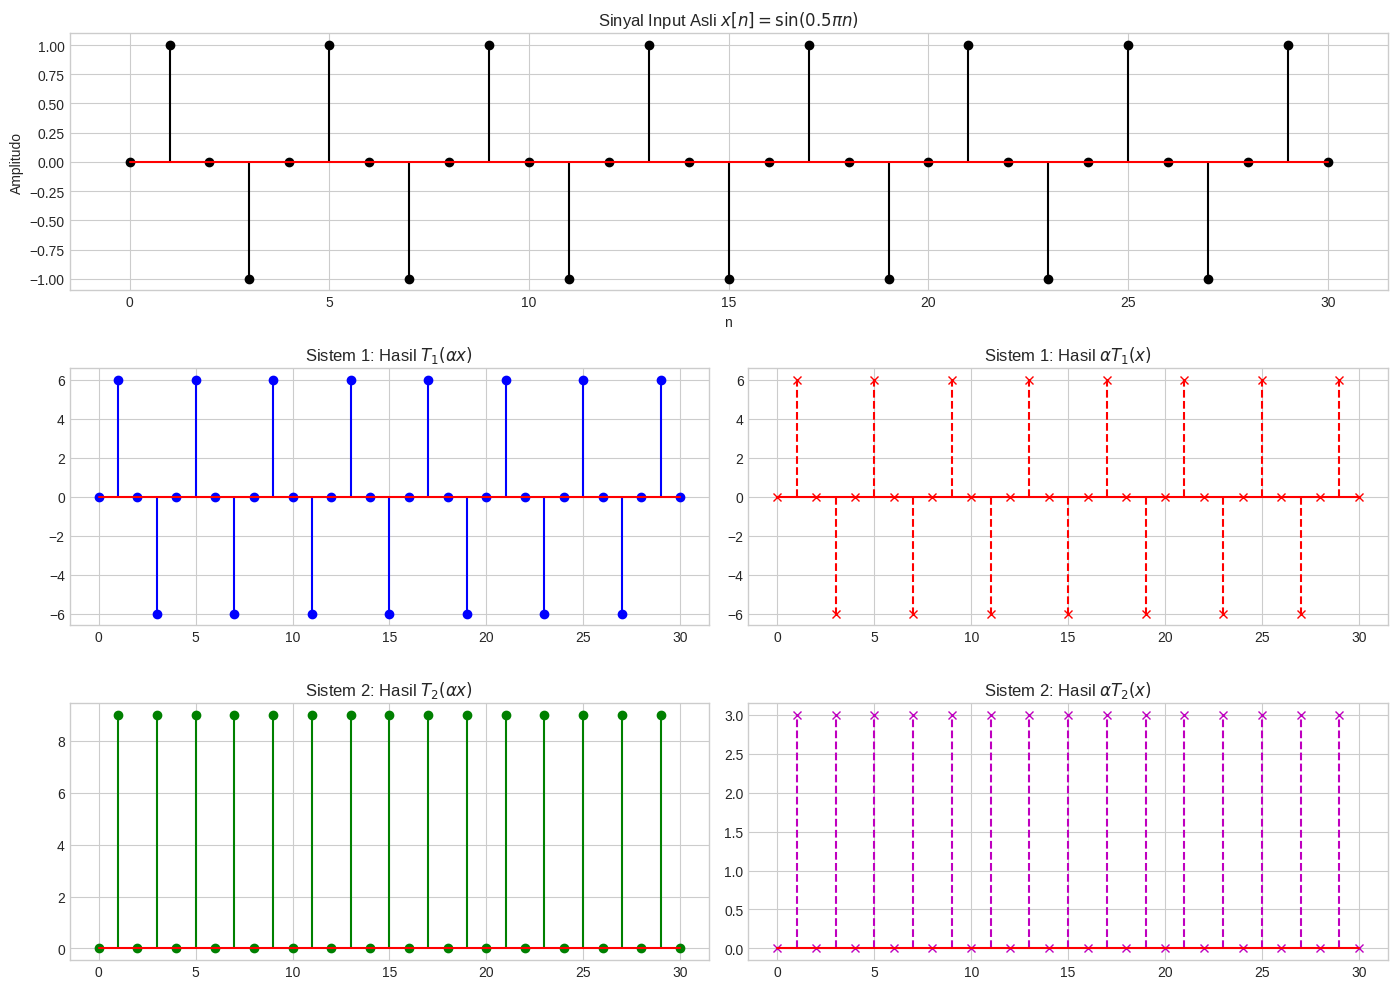

In [ ]:
# Setup sinyal input tunggal x[n] = x1[n]
x_input = x1
alpha_val = 3.0

# Perhitungan Sistem 1: T1(x) = 2x
lhs_t1 = T1(alpha_val * x_input) # T(a*x)
rhs_t1 = alpha_val * T1(x_input) # a*T(x)

# Perhitungan Sistem 2: T2(x) = x^2
lhs_t2 = T2(alpha_val * x_input) # T(a*x)
rhs_t2 = alpha_val * T2(x_input) # a*T(x)

# Visualisasi Plot Perbandingan Sesuai Instruksi Tugas
plt.figure(figsize=(14, 10))

# 1. Plot Sinyal Input Asli x[n]
plt.subplot(3, 1, 1)
plt.stem(n, x_input, linefmt='k-', markerfmt='ko', basefmt='r-')
plt.title(r'Sinyal Input Asli $x[n] = \sin(0.5\pi n)$')
plt.xlabel('n')
plt.ylabel('Amplitudo')
plt.grid(True)

# 2. Plot Perbandingan Homogenitas Sistem 1 (T1)
plt.subplot(3, 2, 3)
plt.stem(n, lhs_t1, linefmt='b-', markerfmt='bo', basefmt='r-')
plt.title(r'Sistem 1: Hasil $T_1(\alpha x)$')
plt.grid(True)

plt.subplot(3, 2, 4)
plt.stem(n, rhs_t1, linefmt='r--', markerfmt='rx', basefmt='r-')
plt.title(r'Sistem 1: Hasil $\alpha T_1(x)$')
plt.grid(True)

# 3. Plot Perbandingan Homogenitas Sistem 2 (T2)
plt.subplot(3, 2, 5)
plt.stem(n, lhs_t2, linefmt='g-', markerfmt='go', basefmt='r-')
plt.title(r'Sistem 2: Hasil $T_2(\alpha x)$')
plt.grid(True)

plt.subplot(3, 2, 6)
plt.stem(n, rhs_t2, linefmt='m--', markerfmt='mx', basefmt='r-')
plt.title(r'Sistem 2: Hasil $\alpha T_2(x)$')
plt.grid(True)

plt.tight_layout()
plt.show()

C.2 UJI ADDITIVITAS

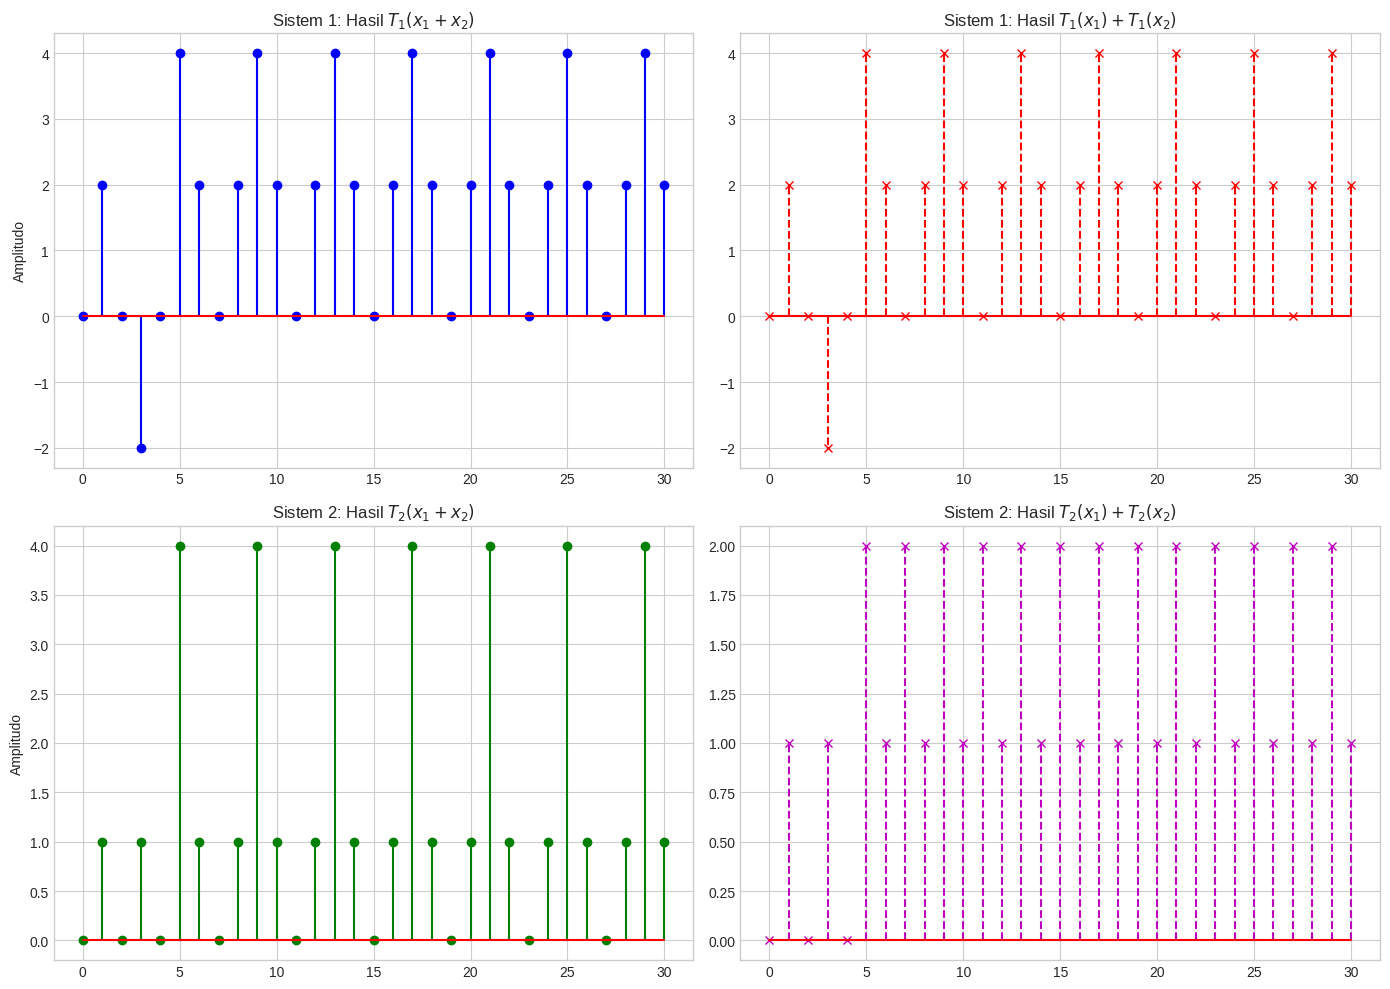

=== HASIL PERHITUNGAN SELISIH (ADDITIVITAS) ===
Total Selisih Sisi Kiri & Kanan pada Sistem 1 (T1) : 0.0
Total Selisih Sisi Kiri & Kanan pada Sistem 2 (T2) : 26.0


In [ ]:
# Perhitungan Uji Additivitas untuk Sistem 1: T1(x) = 2x
lhs_add_t1 = T1(x1 + x2)  # T1(x1 + x2)
rhs_add_t1 = T1(x1) + T1(x2)  # T1(x1) + T1(x2)
diff_t1 = np.sum(np.abs(lhs_add_t1 - rhs_add_t1))  # Hitung selisih mutlak

# Perhitungan Uji Additivitas untuk Sistem 2: T2(x) = x^2
lhs_add_t2 = T2(x1 + x2)  # T2(x1 + x2)
rhs_add_t2 = T2(x1) + T2(x2)  # T2(x1) + T2(x2)
diff_t2 = np.sum(np.abs(lhs_add_t2 - rhs_add_t2))  # Hitung selisih mutlak

# Visualisasi Plot Perbandingan Sesuai Instruksi Tugas
plt.figure(figsize=(14, 10))

# 1. Plot Hasil Uji Sistem 1 (T1)
plt.subplot(2, 2, 1)
plt.stem(n, lhs_add_t1, linefmt='b-', markerfmt='bo', basefmt='r-')
plt.title(r'Sistem 1: Hasil $T_1(x_1 + x_2)$')
plt.ylabel('Amplitudo')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.stem(n, rhs_add_t1, linefmt='r--', markerfmt='rx', basefmt='r-')
plt.title(r'Sistem 1: Hasil $T_1(x_1) + T_1(x_2)$')
plt.grid(True)

# 2. Plot Hasil Uji Sistem 2 (T2)
plt.subplot(2, 2, 3)
plt.stem(n, lhs_add_t2, linefmt='g-', markerfmt='go', basefmt='r-')
plt.title(r'Sistem 2: Hasil $T_2(x_1 + x_2)$')
plt.ylabel('Amplitudo')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.stem(n, rhs_add_t2, linefmt='m--', markerfmt='mx', basefmt='r-')
plt.title(r'Sistem 2: Hasil $T_2(x_1) + T_2(x_2)$')
plt.grid(True)

plt.tight_layout()
plt.show()

# Menampilkan selisih nilai numerik antara kedua sisi persamaan
print("=== HASIL PERHITUNGAN SELISIH (ADDITIVITAS) ===")
print(f"Total Selisih Sisi Kiri & Kanan pada Sistem 1 (T1) : {diff_t1}")
print(f"Total Selisih Sisi Kiri & Kanan pada Sistem 2 (T2) : {round(diff_t2, 4)}")